<a href="https://colab.research.google.com/github/SeiDra/lending-club-prediction/blob/scindage-du-notebook-FeatureEngineering%2FModeling/du_sda_ml2_P4_modeling.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# PROJET 7 : Loan Default Prediction
Partie N°4 — Modélisation & Évaluation

Contenu :
- Import des données transformées (sortie du P3)
- Gestion du déséquilibre (Undersampling)
- Feature Selection
- Évaluation LightGBM (Cross-Validation 5-fold)
- Optimisation du modèle
- Évaluation finale sur le Test Set (une seule fois)
- Interprétabilité et conclusions

In [32]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scipy.stats as sps
import seaborn as sns

from sklearn.metrics import (accuracy_score, classification_report,
                              confusion_matrix, f1_score, precision_score,
                              recall_score, roc_auc_score, roc_curve,
                              precision_recall_curve)
from sklearn.model_selection import StratifiedKFold, RandomizedSearchCV

In [33]:
train_X = pd.read_parquet("DATA/03_train_X.parquet")
train_y = pd.read_parquet("DATA/03_train_y.parquet").squeeze()
test_X = pd.read_parquet("DATA/03_test_X.parquet")
test_y = pd.read_parquet("DATA/03_test_y.parquet").squeeze()

# Lecture du nom de la cible (pour les fonctions utilitaires)
with open("CONFIG/target_config.txt", "r") as f:
    target_col = f.read().strip()

print(f"Train X : {train_X.shape} | Train y : {train_y.shape}")
print(f"Test  X : {test_X.shape}  | Test  y : {test_y.shape}")
print(f"\nRatio défaut train : {train_y.mean():.2%}")
print(f"Ratio défaut test  : {test_y.mean():.2%}")

Train X : (1166919, 86) | Train y : (1166919,)
Test  X : (291730, 86)  | Test  y : (291730,)

Ratio défaut train : 19.00%
Ratio défaut test  : 19.00%


In [34]:
from imblearn.under_sampling import RandomUnderSampler

undersampler = RandomUnderSampler(random_state=42)
# On crée un jeu d'entraînement rééquilibré
train_X_model, train_y_model = undersampler.fit_resample(train_X, train_y)

print(f"Undersampling : {train_X_model.shape}")
print(train_y_model.value_counts())

Undersampling : (443384, 86)
loan_condition_int
0    221692
1    221692
Name: count, dtype: int64


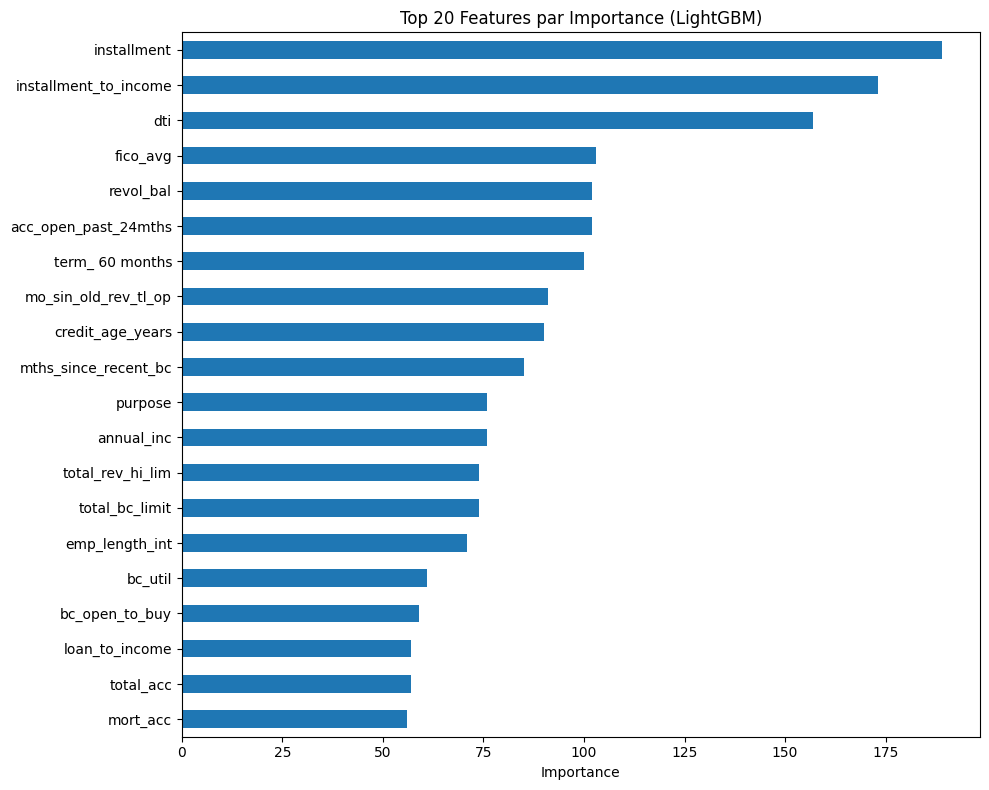


15 features retenues : ['installment', 'installment_to_income', 'dti', 'fico_avg', 'revol_bal', 'acc_open_past_24mths', 'term_ 60 months', 'mo_sin_old_rev_tl_op', 'credit_age_years', 'mths_since_recent_bc', 'purpose', 'annual_inc', 'total_rev_hi_lim', 'total_bc_limit', 'emp_length_int']


In [35]:
# Méthode : Feature Importance via un modèle LightGBM rapide
from lightgbm import LGBMClassifier

# Entraîner un modèle rapide pour obtenir les importances
lgbm_quick = LGBMClassifier(
    n_estimators=100,
    random_state=42,
    verbose=-1
)
lgbm_quick.fit(train_X_model, train_y_model)

# Extraire et afficher les importances
importances = pd.Series(lgbm_quick.feature_importances_, index=train_X_model.columns)
importances = importances.sort_values(ascending=False)

plt.figure(figsize=(10, 8))
importances.head(20).plot(kind='barh')
plt.title("Top 20 Features par Importance (LightGBM)")
plt.xlabel("Importance")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

# Sélectionner les features avec importance > 0 (ou un seuil personnalisé)
N_TOP_FEATURES = 15
vars_final = importances.head(N_TOP_FEATURES).index.tolist()
print(f"\n{N_TOP_FEATURES} features retenues : {vars_final}")

# Filtrer train et test
train_X_selected = train_X_model[vars_final]
test_X_selected = test_X[vars_final]

In [36]:
# Optimisation de LightGBM avec RandomizedSearchCV

param_dist = {
    'n_estimators': [100, 200, 300, 500],
    'max_depth': [3, 5, 7, 10, -1],
    'learning_rate': [0.01, 0.05, 0.1, 0.2],
    'num_leaves': [15, 31, 63, 127],
    'min_child_samples': [10, 20, 50],
    'subsample': [0.7, 0.8, 0.9, 1.0],
    'colsample_bytree': [0.7, 0.8, 0.9, 1.0],
}

search = RandomizedSearchCV(
    LGBMClassifier(random_state=42, verbose=-1),
    param_distributions=param_dist,
    n_iter=30,
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
    scoring='average_precision',
    random_state=42,
    n_jobs=-1,
    verbose=1
)

# Entraîner sur le jeu d'entraînement rééquilibré (features sélectionnées)
search.fit(train_X_selected, train_y_model)

print(f"\nMeilleurs paramètres : {search.best_params_}")
print(f"Meilleure Average Precision (CV) : {search.best_score_:.4f}")

best_model = search.best_estimator_

Fitting 5 folds for each of 30 candidates, totalling 150 fits

Meilleurs paramètres : {'subsample': 1.0, 'num_leaves': 127, 'n_estimators': 500, 'min_child_samples': 20, 'max_depth': 7, 'learning_rate': 0.05, 'colsample_bytree': 0.8}
Meilleure Average Precision (CV) : 0.6781


RÉSUMÉ DES MÉTRIQUES CLÉS - TEST SET
🔹 AUPRC (Average Precision) : 0.3419 → Robustesse globale du modèle (indépendant du déséquilibre).
🔹 Recall (Classe 1)         : 0.6534 → Protection du capital : taux de détection des vrais défauts.
🔹 F2-Score                  : 0.5234 → Métrique métier : accorde 2x plus de poids au Recall qu'à la Précision.
🔹 KS Statistic              : 0.2812 → Séparation des distributions (Bon vs Mauvais crédit).


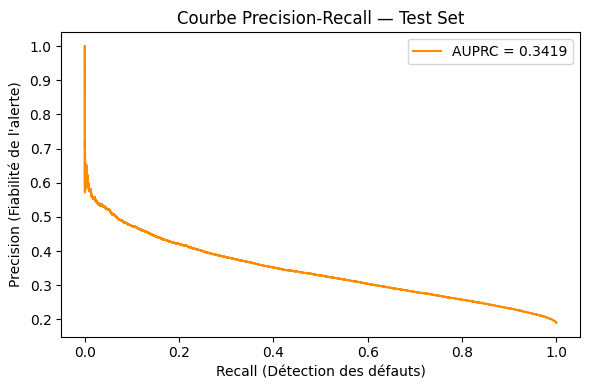

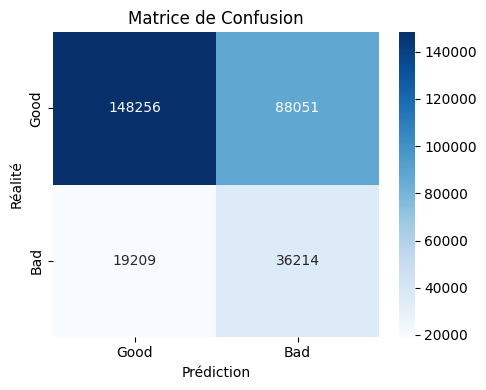

In [37]:
from sklearn.metrics import fbeta_score, average_precision_score

# On établit l'évaluation finale sur le test set
y_pred = best_model.predict(test_X_selected)
y_pred_proba = best_model.predict_proba(test_X_selected)[:, 1]

# Calcul des métriques essentielles
recall_classe1 = recall_score(test_y, y_pred)
f2_score = fbeta_score(test_y, y_pred, beta=2)
auprc = average_precision_score(test_y, y_pred_proba)

# KS Statistic
mask = test_y.astype(bool).values
ks_stat = sps.ks_2samp(y_pred_proba[mask], y_pred_proba[~mask])[0]

print("=" * 60)
print("RÉSUMÉ DES MÉTRIQUES CLÉS - TEST SET")
print("=" * 60)
print(f"🔹 AUPRC (Average Precision) : {auprc:.4f} → Robustesse globale du modèle (indépendant du déséquilibre).")
print(f"🔹 Recall (Classe 1)         : {recall_classe1:.4f} → Protection du capital : taux de détection des vrais défauts.")
print(f"🔹 F2-Score                  : {f2_score:.4f} → Métrique métier : accorde 2x plus de poids au Recall qu'à la Précision.")
print(f"🔹 KS Statistic              : {ks_stat:.4f} → Séparation des distributions (Bon vs Mauvais crédit).")
print("=" * 60)

# Courbe Precision-Recall (pour appui visuel de l'AUPRC)
precision_curve, recall_curve, _ = precision_recall_curve(test_y, y_pred_proba)
plt.figure(figsize=(6, 4))
plt.plot(recall_curve, precision_curve, label=f'AUPRC = {auprc:.4f}', color='darkorange')
plt.xlabel('Recall (Détection des défauts)')
plt.ylabel('Precision (Fiabilité de l\'alerte)')
plt.title('Courbe Precision-Recall — Test Set')
plt.legend()
plt.tight_layout()
plt.show()

# Matrice de confusion rapide (pour la lisibilité)
cm = confusion_matrix(test_y, y_pred)
plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Good', 'Bad'], yticklabels=['Good', 'Bad'])
plt.xlabel('Prédiction')
plt.ylabel('Réalité')
plt.title('Matrice de Confusion')
plt.tight_layout()
plt.show()

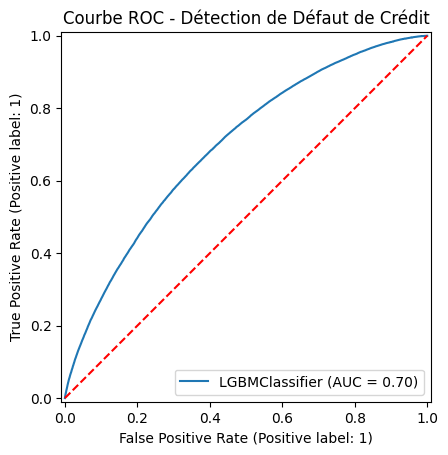

In [41]:
import matplotlib.pyplot as plt
from sklearn.metrics import RocCurveDisplay

RocCurveDisplay.from_estimator(best_model, test_X_selected, test_y)
plt.plot([0, 1], [0, 1], color='red', linestyle='--') # Ligne de hasard
plt.title("Courbe ROC - Détection de Défaut de Crédit")
plt.show()

In [42]:
from sklearn.metrics import precision_score, roc_auc_score, classification_report

# 1. Calcul des prédictions (classes et probabilités)
# Remplace 'X_test' et 'y_test' par les noms de tes variables si elles sont différentes
y_pred = best_model.predict(test_X_selected)
y_proba = best_model.predict_proba(test_X_selected)[:, 1]

# 2. Calcul des métriques spécifiques
precision = precision_score(test_y, y_pred)
auc_roc = roc_auc_score(test_y, y_proba)

# 3. Affichage propre
print(f"========================================")
print(f"   RÉSULTATS FINAUX DU MODÈLE LGBM")
print(f"========================================")
print(f"Précision (Classe 1 - Bad Loan) : {precision:.4f}")
print(f"AUC-ROC Score                   : {auc_roc:.4f}")
print(f"========================================")

# Optionnel : Afficher le rapport complet pour voir la précision de la classe 0 aussi
print("\nDétails par classe :")
print(classification_report(test_y, y_pred))

   RÉSULTATS FINAUX DU MODÈLE LGBM
Précision (Classe 1 - Bad Loan) : 0.2914
AUC-ROC Score                   : 0.6954

Détails par classe :
              precision    recall  f1-score   support

           0       0.89      0.63      0.73    236307
           1       0.29      0.65      0.40     55423

    accuracy                           0.63    291730
   macro avg       0.59      0.64      0.57    291730
weighted avg       0.77      0.63      0.67    291730



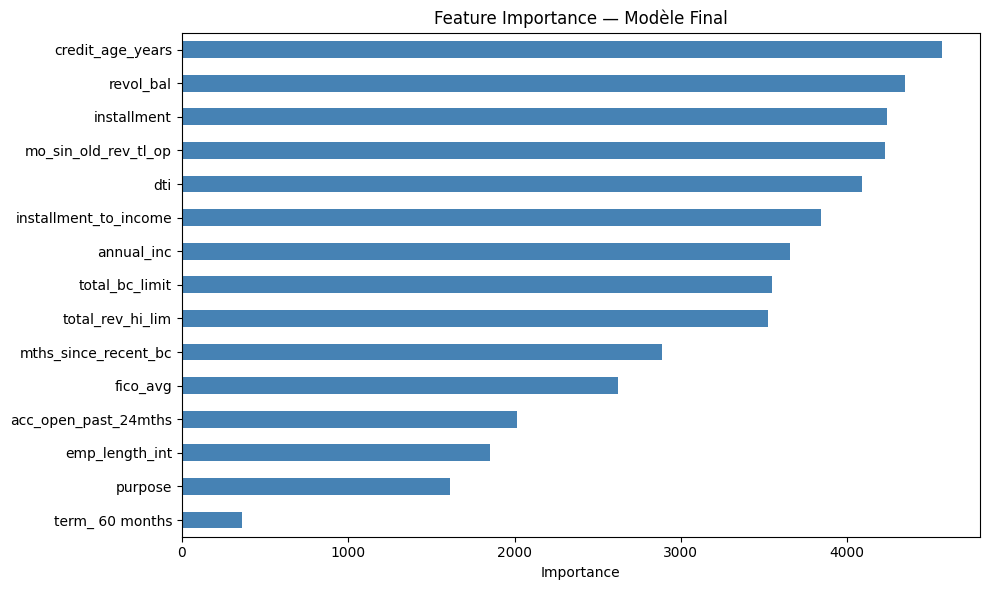

In [38]:
# Feature Importance du modèle final
importances_final = pd.Series(best_model.feature_importances_,
                               index=test_X_selected.columns)
importances_final = importances_final.sort_values(ascending=True)

plt.figure(figsize=(10, 6))
importances_final.plot(kind='barh', color='steelblue')
plt.title("Feature Importance — Modèle Final")
plt.xlabel("Importance")
plt.tight_layout()
plt.show()

In [39]:
# (Optionnel) SHAP Values
# import shap
# explainer = shap.TreeExplainer(best_model)
# shap_values = explainer.shap_values(test_X_selected)
# shap.summary_plot(shap_values[1], test_X_selected)

In [40]:
# Conclusions et Recommandations
# Résumer :
# 1. Les performances du modèle final (AUC, F1, KS, etc.)
# 2. Les 5 variables les plus influentes et leur interprétation métier
# 3. Les recommandations concrètes pour l'institution financière
# 4. Les limites du modèle et les pistes d'amélioration